1 : Fibonacci-Zahlen
Schreiben Sie eine Python-Funktion, die für gegebenes n die Fibonacci-Zahl fn berechnet. (Konvention:
f0 = 0, f1 = 1).

In [24]:
def fib(n: int) -> int:
    """Rekursive Berechnung der n-ten Fibonacci-Zahl.

    Args:
        n (int): Index der Fibonacci-Zahl.

    Returns:
        int: Die n-te Fibonacci-Zahl.
    """
    if not isinstance(n, int):
        raise TypeError("n muss vom Typ int sein")
    if n < 0:
        raise ValueError("n darf nicht kleiner als null sein")
    if n == 0:
        return 0.0
    elif n == 1:
        return 1.0
    else:
        return fib(n - 1) + fib(n - 2)
    
print(" Die 10. Fibonacci-Zahl ist:", fib(10))

 Die 10. Fibonacci-Zahl ist: 55.0


2 : Schrittweise Propagation des harmonischen Oszillators

a: Näherung der Dynamik durch Iteration

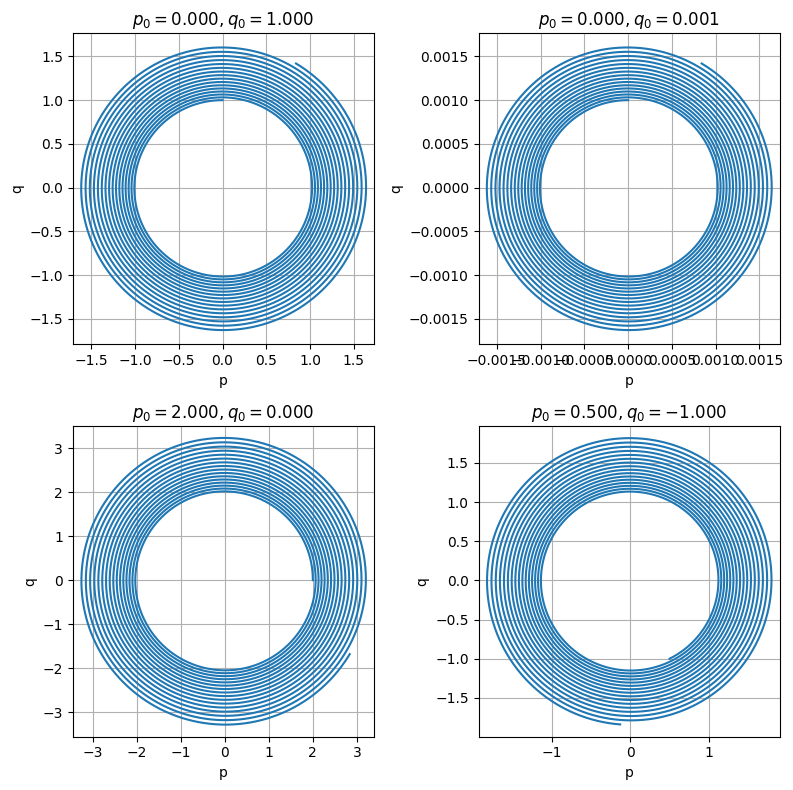

In [25]:
import matplotlib.pyplot as plt
from numpy import array, linspace

def oscillator_step(current_p: float, current_q: float, timestep = .01) -> tuple[float, float]:
    """Führt einen Zeitschritt für einen Oszillator durch.

    Args:
        current_p (float): Der aktuelle Impuls des Oszillators.
        current_q (float): Die aktuelle verallgemeinerte Position des Oszillators.
        timestep (float): Die Zeitdauer des Zeitschritts.

    Returns:
        NDArray[np.float64]: Der neue Zustand des Oszillators.
    """
    omega = 1.0
    new_q = current_q + omega * current_p * timestep
    new_p = current_p - omega * current_q * timestep
    return new_p, new_q

def simulate(p0: float, q0: float, t: array, dt: float):
    p_list, q_list = [p0], [q0]
    for _ in t[1:]:
        new_p, new_q = oscillator_step(p_list[-1], q_list[-1], dt)
        p_list.append(new_p); q_list.append(new_q)
    return array(p_list), array(q_list)

t = linspace(0, 100, 10000)
dt = t[1] - t[0]
starts = [(0., 1.0), (0., 0.001), (2.0, 0.0), (0.5, -1.0)]

fig, axs = plt.subplots(2, 2, figsize=(8, 8))
for ax, (p0, q0) in zip(axs.ravel(), starts):
    p, q = simulate(p0, q0, t, dt)
    ax.plot(p, q, '-')
    ax.set_title(r'$p_0=%.3f, q_0=%.3f$' % (p0, q0))
    ax.set_xlabel("p")
    ax.set_ylabel("q")
    ax.axis("equal")
    ax.grid(True)

plt.tight_layout()
plt.show()

b: Sequenzielle Updates

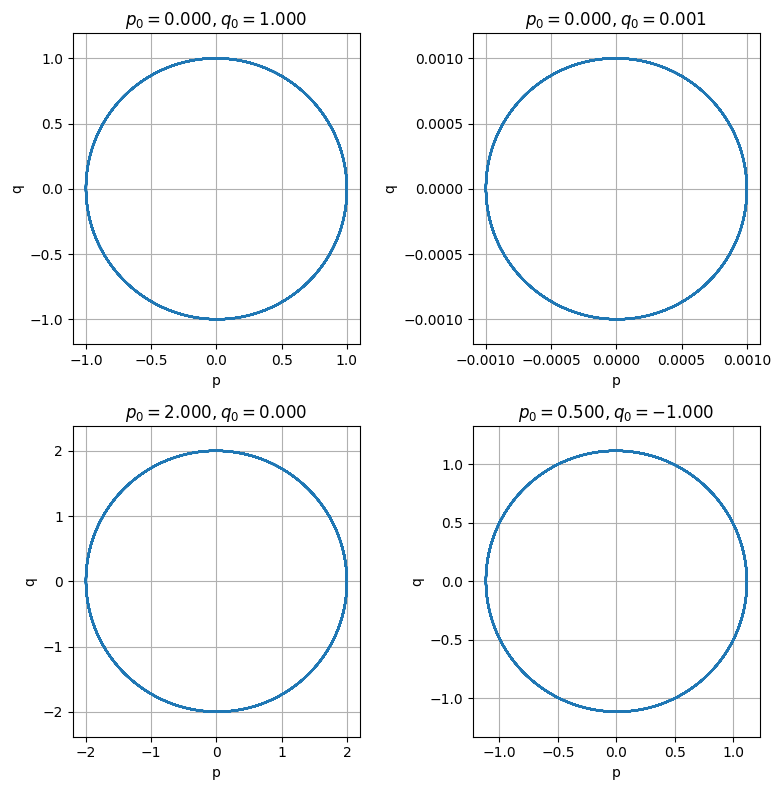

In [26]:
import matplotlib.pyplot as plt
from numpy import array, linspace

def oscillator_step(current_p: float, current_q: float, timestep = .01) -> tuple[float, float]:
    """Führt einen sequenziellen Zeitschritt für einen Oszillator durch.

    Args:
        current_p (float): Der aktuelle Impuls des Oszillators.
        current_q (float): Die aktuelle verallgemeinerte Position des Oszillators.
        timestep (float): Die Zeitdauer des Zeitschritts.

    Returns:
        NDArray[np.float64]: Der neue Zustand des Oszillators.
    """
    omega = 1.0
    new_q = current_q + omega * current_p * timestep
    new_p = current_p - omega * new_q * timestep
    return new_p, new_q

def simulate(p0: float, q0: float, t: array, dt: float):
    p_list, q_list = [p0], [q0]
    for _ in t[1:]:
        new_p, new_q = oscillator_step(p_list[-1], q_list[-1], dt)
        p_list.append(new_p); q_list.append(new_q)
    return array(p_list), array(q_list)

t = linspace(0, 100, 10000)
dt = t[1] - t[0]
starts = [(0., 1.0), (0., 0.001), (2.0, 0.0), (0.5, -1.0)]

fig, axs = plt.subplots(2, 2, figsize=(8, 8))
for ax, (p0, q0) in zip(axs.ravel(), starts):
    p, q = simulate(p0, q0, t, dt)
    ax.plot(p, q, '-')
    ax.set_title(r'$p_0=%.3f, q_0=%.3f$' % (p0, q0))
    ax.set_xlabel("p")
    ax.set_ylabel("q")
    ax.axis("equal")
    ax.grid(True)

plt.tight_layout()
plt.show()

3 : Bewegungsgleichungen und Solver

a: solve_ivp

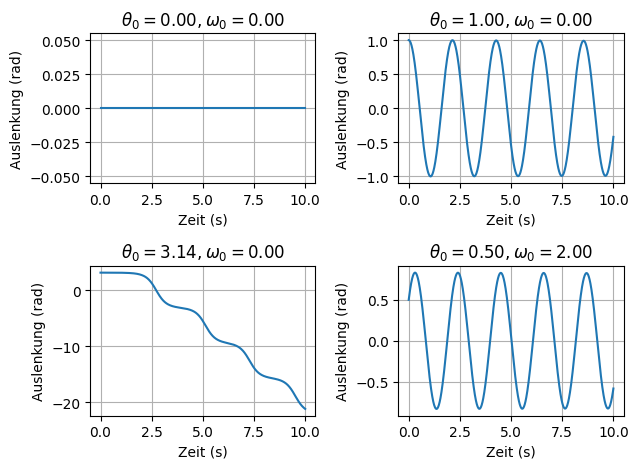

In [ ]:
from numpy.typing import NDArray
from numpy import float64, sin
from scipy.integrate import solve_ivp

def math_pendulum(y: NDArray[float64]) -> NDArray[float64]:
    """Bewegungsgleichungen für das mathematische Pendel.

    Args:
        y (NDArray[float64]): Der aktuelle Zustand des Systems [theta, omega].

    Returns:
        NDArray[float64]: Die Ableitungen [dtheta/dt, domega/dt].
    """
    g = 9.81
    L = 1.0
    theta, omega = y
    dtheta_dt = omega
    domega_dt = - (g / L) * sin(theta)
    return array([dtheta_dt, domega_dt])

def simulate_pendulum(theta0: float, omega0: float, t_span: tuple[float, float], t_eval: NDArray[float64]):
    """Simuliert die Bewegung des mathematischen Pendels.

    Args:
        theta0 (float): Anfangsauslenkung in Radiant.
        omega0 (float): Anfangsgeschwindigkeit in Radiant/s.
        t_span (tuple[float, float]): Zeitspanne für die Simulation (t0, tf).
        t_eval (NDArray[float64]): Zeitpunkte, an denen die Lösung ausgewertet wird.

    Returns:
        OdeResult: Ergebnis der Integration mit Zeitpunkten und Zuständen.
    """
    y0 = array([theta0, omega0])
    solution = solve_ivp(math_pendulum, t_span, y0, t_eval=t_eval, method='RK45')
    return solution

t_eval = linspace(0, 10, 1000)
starts = [(0.0, 0.0), (1.0, 0.0), (3.14, 0.0), (0.5, 2.0)]

fig, axs = plt.subplots(2, 2)
for ax, (theta0, omega0) in zip(axs.ravel(), starts):
    sol = simulate_pendulum(theta0, omega0, (0, 10), t_eval)
    ax.plot(sol.t, sol.y[0], '-')
    ax.set_title(r'$\theta_0=%.2f, \omega_0=%.2f$' % (theta0, omega0))
    ax.set_xlabel("Zeit (s)")
    ax.set_ylabel("Auslenkung (rad)")
    ax.grid(visible=True)

plt.tight_layout()
plt.show()

b: g und L als Variablen

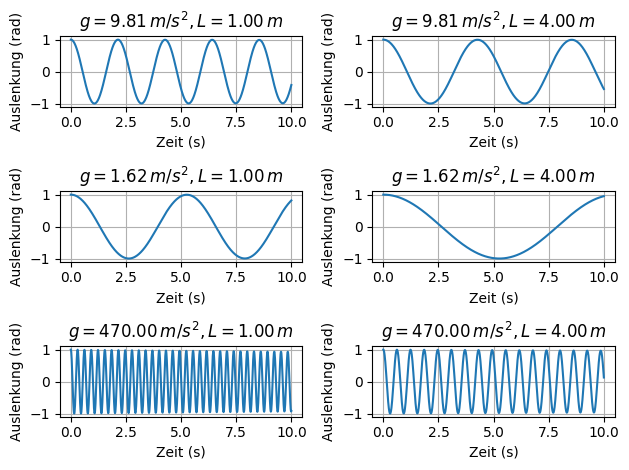

In [31]:
from numpy.typing import NDArray
from numpy import float64, sin
from scipy.integrate import solve_ivp

def math_pendulum(t: float, y: NDArray[float64], g: float, L: float) -> NDArray[float64]:
    """Bewegungsgleichungen für das mathematische Pendel.

    Args:
        t (float): Die aktuelle Zeit.
        y (NDArray[float64]): Der aktuelle Zustand des Systems [theta, omega].

    Returns:
        NDArray[float64]: Die Ableitungen [dtheta/dt, domega/dt].
    """
    theta, omega = y
    dtheta_dt = omega
    domega_dt = - (g / L) * sin(theta)
    return array([dtheta_dt, domega_dt])

def simulate_pendulum(theta0: float, omega0: float, g: float, L: float, t_span: tuple[float, float], t_eval: NDArray[float64]):
    """Simuliert die Bewegung des mathematischen Pendels.

    Args:
        theta0 (float): Anfangsauslenkung in Radiant.
        omega0 (float): Anfangsgeschwindigkeit in Radiant/s.
        t_span (tuple[float, float]): Zeitspanne für die Simulation (t0, tf).
        t_eval (NDArray[float64]): Zeitpunkte, an denen die Lösung ausgewertet wird.

    Returns:
        OdeResult: Ergebnis der Integration mit Zeitpunkten und Zuständen.
    """
    args = (g, L)
    y0 = array([theta0, omega0])
    solution = solve_ivp(math_pendulum, t_span, y0, t_eval=t_eval, method='RK45', args=args)
    return solution

t_eval = linspace(0, 10, 1000)
start = (1.0, 0.0)
gs_and_Ls = [(9.81, 1.0), (9.81, 4.0), (1.62, 1.0), (1.62, 4.0), (470.0, 1.0), (470.0, 4.0)]

fig, axs = plt.subplots(3, 2)
for ax, (g, L) in zip(axs.ravel(), gs_and_Ls):
    sol = simulate_pendulum(start[0], start[1], g, L, (0, 10), t_eval)
    ax.plot(sol.t, sol.y[0], '-')
    ax.set_title(r'$g=%.2f\,m/s^2, L=%.2f\,m$' % (g, L))
    ax.set_xlabel("Zeit (s)")
    ax.set_ylabel("Auslenkung (rad)")
    ax.grid(visible=True)

plt.tight_layout()
plt.show()